In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(f"D:\Car\Customer_Segmentation\Course_ML_Project\AI_Impact_on_Jobs_2030.csv")

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Hp\AppData\Local\Temp\ipykernel_5040\1434565926.py:1: SyntaxWarning: invalid escape sequence '\C'
  df=pd.read_csv(f"D:\Car\Customer_Segmentation\Course_ML_Project\AI_Impact_on_Jobs_2030.csv")


In [4]:
df.head()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


In [5]:
df.shape

(3000, 18)

<Axes: xlabel='Education_Level', ylabel='Years_Experience'>

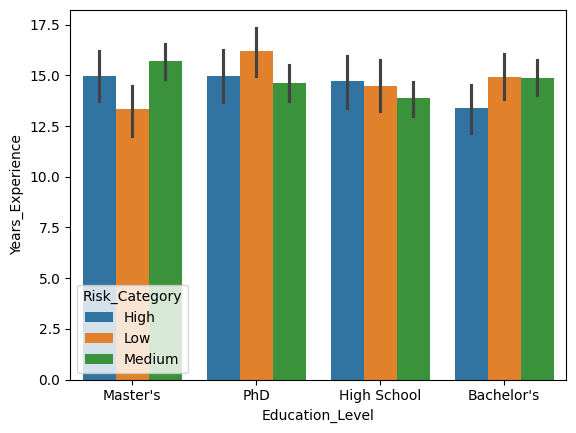

In [6]:
sns.barplot(data=df,x="Education_Level",y="Years_Experience",hue="Risk_Category")

<Axes: xlabel='Average_Salary', ylabel='Job_Title'>

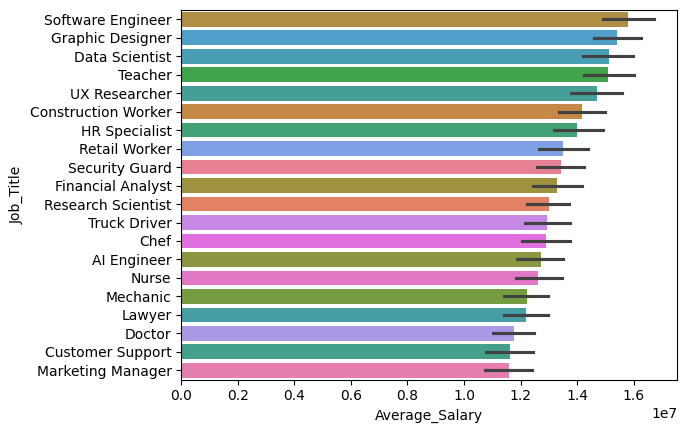

In [7]:
ascending_order=df.groupby("Job_Title")["Average_Salary"].sum().sort_values(ascending=False).index
sns.barplot(data=df,y="Job_Title",x="Average_Salary",hue="Job_Title",order=ascending_order,estimator="sum")

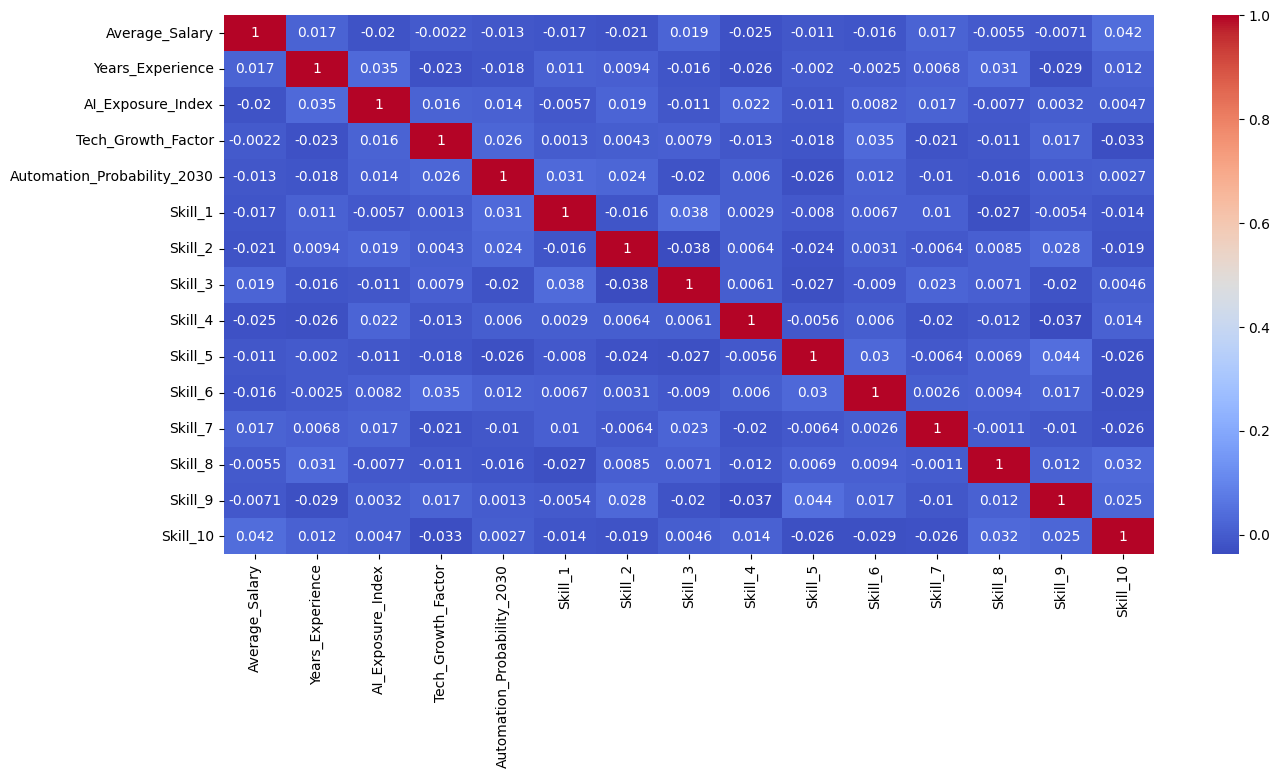

In [8]:
numeric_df=df.select_dtypes(include=np.number)
plt.figure(figsize=(15,7))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [9]:
df.describe()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.995343,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,34608.088767,8.739788,0.284004,0.287669,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,30030.000000,0.000000,0.000000,0.500000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58640.000000,7.000000,0.260000,0.740000,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,119086.500000,22.000000,0.740000,1.240000,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000
max,149798.000000,29.000000,1.000000,1.500000,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
Education_mapping={"High School":1,"Bachelor's":2,"Master's":3,"PhD":4}
Risk_mapping={"Low":1,"Medium":2,"High":3}

df["Education_Level_Encoded"]=df["Education_Level"].map(Education_mapping)
df["Risk_Category_Encoded"]=df["Risk_Category"].map(Risk_mapping)

df["Job_Title_Encoded"]=encoder.fit_transform(df["Job_Title"])
df_encoded=df.drop(columns=["Job_Title","Education_Level","Risk_Category"],inplace=True)

In [11]:
df.head()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10,Education_Level_Encoded,Risk_Category_Encoded,Job_Title_Encoded
0,45795,28,0.18,1.28,0.85,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00,3,3,15
1,133355,20,0.62,1.11,0.05,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98,4,1,13
2,146216,2,0.86,1.18,0.81,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83,1,3,2
3,136530,13,0.39,0.68,0.60,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33,4,2,16
4,70397,22,0.52,1.46,0.64,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42,1,2,6


In [12]:
safe_features=["Job_Title_Encoded", "Average_Salary", "Years_Experience", "Education_Level_Encoded", 
    "AI_Exposure_Index", "Tech_Growth_Factor",
    "Skill_1", "Skill_2", "Skill_3", "Skill_4", "Skill_5", 
    "Skill_6", "Skill_7", "Skill_8", "Skill_9", "Skill_10"]

In [13]:
X=df.drop(["Risk_Category_Encoded","Automation_Probability_2030"],axis=1)

In [14]:
X.head()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10,Education_Level_Encoded,Job_Title_Encoded
0,45795,28,0.18,1.28,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00,3,15
1,133355,20,0.62,1.11,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98,4,13
2,146216,2,0.86,1.18,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83,1,2
3,136530,13,0.39,0.68,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33,4,16
4,70397,22,0.52,1.46,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42,1,6


In [15]:
from sklearn.model_selection import train_test_split
#X=df[safe_features]
y=df["Risk_Category_Encoded"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

model = Pipeline([("scaler", StandardScaler()),("classifier", RandomForestClassifier(random_state=42))])

In [17]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [18]:
y_pred = model.predict(X_test)

In [19]:
acc = accuracy_score(y_test, y_pred)
re = recall_score(y_test, y_pred, average="weighted")
prec = precision_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {re:.4f}")

Accuracy : 0.9383
Precision: 0.9408
Recall   : 0.9383


                    feature  Importance
15        Job_Title_Encoded    0.460418
0            Average_Salary    0.040879
10                  Skill_7    0.038871
8                   Skill_5    0.038640
6                   Skill_3    0.038422
9                   Skill_6    0.038270
12                  Skill_9    0.038257
2         AI_Exposure_Index    0.037953
3        Tech_Growth_Factor    0.037896
11                  Skill_8    0.037579
4                   Skill_1    0.037316
5                   Skill_2    0.036933
7                   Skill_4    0.036672
13                 Skill_10    0.036056
1          Years_Experience    0.031841
14  Education_Level_Encoded    0.013995


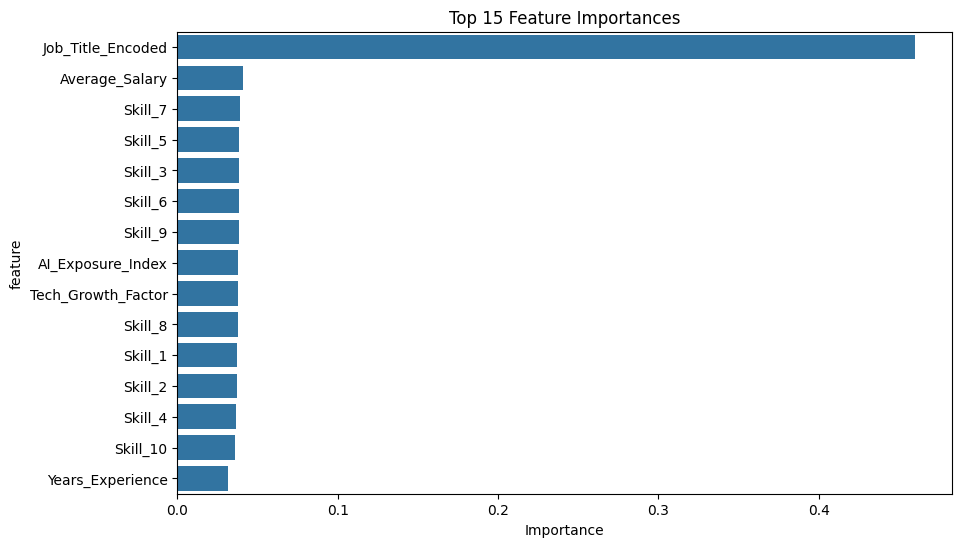

In [ ]:
classifier = model.named_steps["classifier"]

importance_df = (pd.DataFrame({"feature": X.columns,"Importance": classifier.feature_importances_}).sort_values(by="Importance", ascending=False))

print(importance_df)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15),x="Importance",y="feature")
plt.title("Top 15 Feature Importances")
plt.show()

In [21]:
#from sklearn.preprocessing import StandardScaler
#scaler=StandardScaler()
#X_train_scaled=scaler.fit_transform(X_train,y_train)
#X_test_scaled=scaler.transform(X_test)

In [22]:
#from sklearn.ensemble import RandomForestClassifier
#classifier=RandomForestClassifier()
#model=classifier.fit(X_train_scaled,y_train)

In [23]:
#y_pred=model.predict(X_test_scaled)

In [24]:
#from sklearn.metrics import accuracy_score,precision_score,recall_score

#acc=accuracy_score(y_test,y_pred)
#re=recall_score(y_test,y_pred,average="weighted")
#prec=precision_score(y_test,y_pred,average="weighted")

#print("Accuracy: ",acc)
#print("Recall: ",re)
#print("Precision: ",prec)

In [25]:
#importances=model.feature_importances_
#feature_names=X.columns

#importance_df=pd.DataFrame({'feature':feature_names,'Importance':importances}).sort_values(by="Importance",ascending=False)
#print(importance_df)